# 01 · Exploratory Data Analysis
Olist Brazilian E-Commerce, delivered orders Jan 2017 – Aug 2018.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
pd.set_option('display.width', 140)

In [2]:
from ecom.data import warehouse
wh = {n: warehouse.load(n) for n in warehouse.TABLES}
{k: v.shape for k, v in wh.items()}

{'fact_order_items': (108561, 12),
 'fact_orders': (95041, 25),
 'dim_customer': (91977, 7),
 'dim_product': (32951, 10),
 'dim_date': (592, 8)}

## Headline KPIs

In [3]:
from ecom.insights.eda import kpis, make_figures
pd.Series(kpis(wh['fact_orders'], wh['dim_customer'])).round(3)

orders                  9.504100e+04
customers               9.197700e+04
revenue                 1.521820e+07
avg_order_value         1.601220e+02
repeat_customer_rate    3.000000e-02
avg_review_score        4.153000e+00
late_delivery_rate      6.800000e-02
avg_delivery_days       1.216400e+01
dtype: float64

## Figures

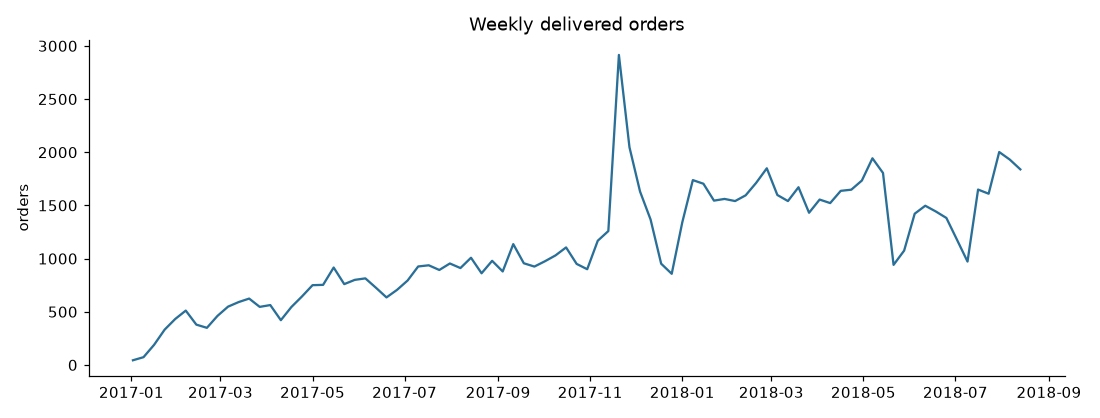

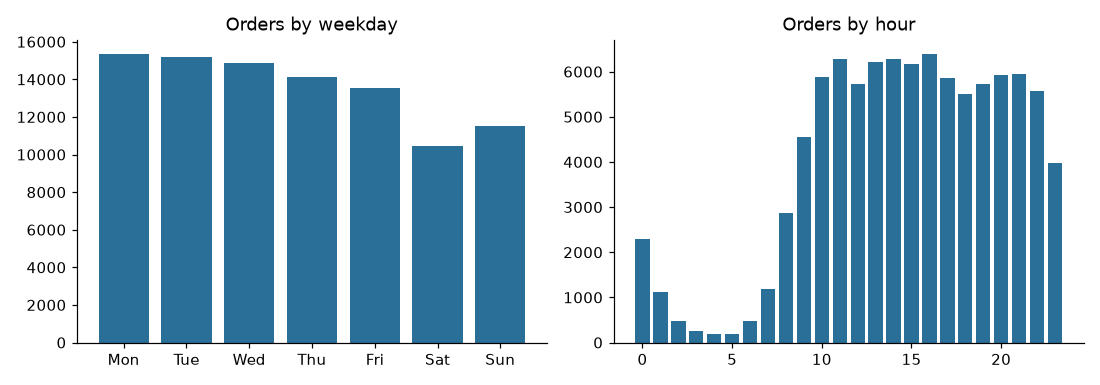

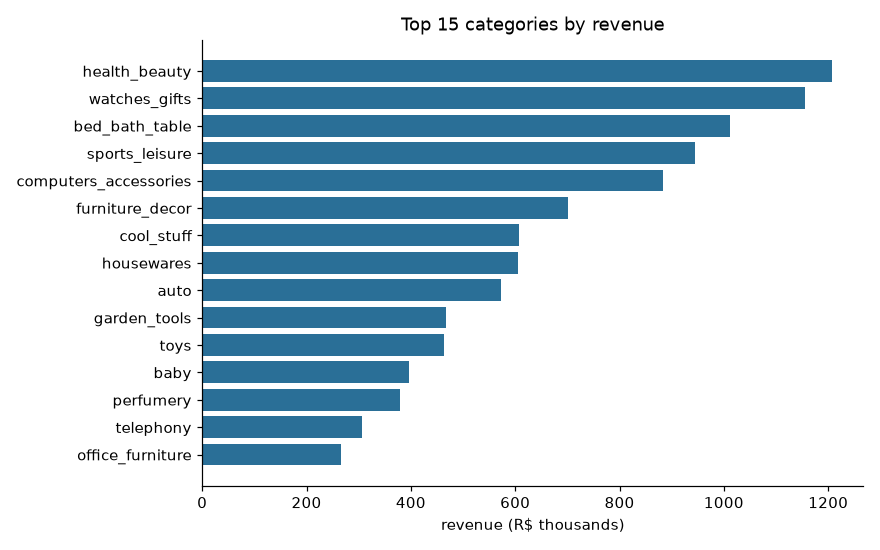

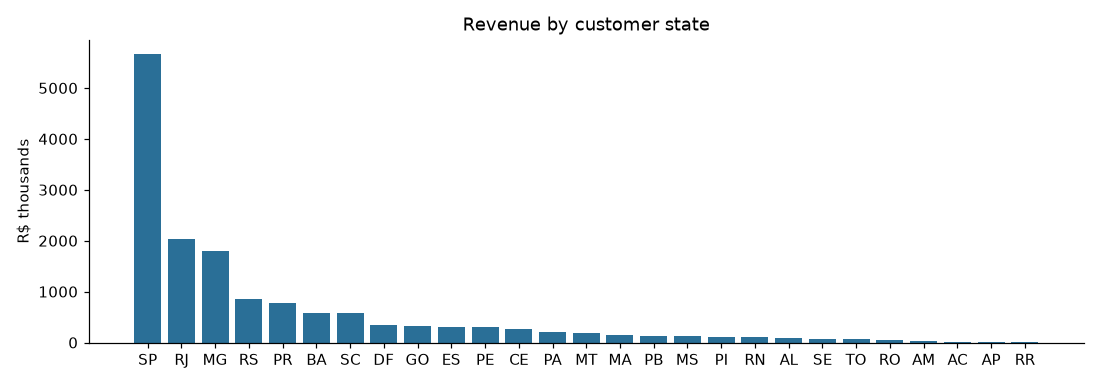

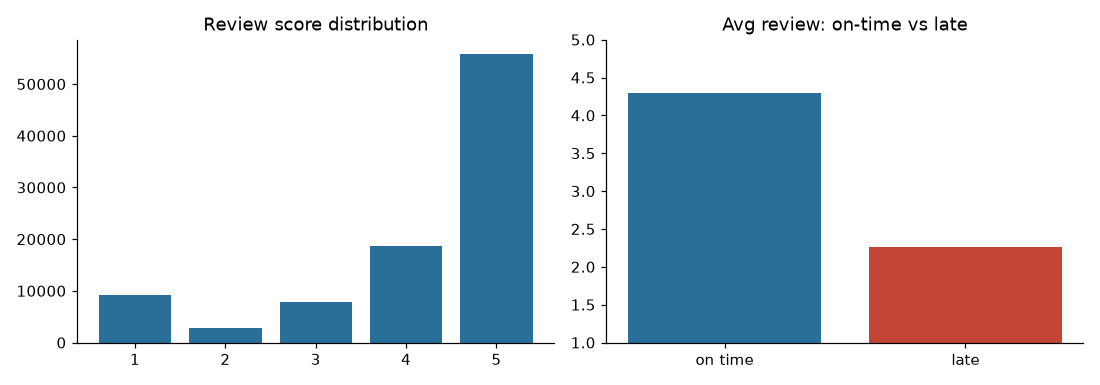

In [4]:
from IPython.display import Image, display
for p in make_figures(wh):
    display(Image(filename=str(p)))

## Customer repeat behaviour
Most customers purchase only once — this shapes the churn framing.

In [5]:
wh['dim_customer']['n_orders'].value_counts().sort_index().head(8)

n_orders
1    89223
2     2532
3      176
4       27
5       10
6        4
7        3
9        1
Name: count, dtype: int64

## Delivery performance by state

In [6]:
wh['fact_orders'].groupby('customer_state').agg(orders=('order_id','count'), avg_days=('delivery_days','mean'), late_rate=('is_late','mean'), review=('review_score','mean')).sort_values('orders', ascending=False).round(2).head(12)

,orders,avg_days,late_rate,review
customer_state,,,,
SP,39671,8.35,0.05,4.24
RJ,12191,14.93,0.12,3.96
MG,11189,11.59,0.05,4.19
RS,5296,14.86,0.06,4.18
PR,4851,11.57,0.04,4.24
SC,3511,14.53,0.08,4.13
BA,3243,18.90,0.12,3.93
DF,2054,12.54,0.06,4.13
ES,1980,15.37,0.11,4.08
